In [1]:
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("All imports done ✅")

All imports done ✅


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/colorectal_cancer_prediction.csv')

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget values:\n", df['Stage_at_Diagnosis'].value_counts())

Mounted at /content/drive
Shape: (89945, 30)

Missing values:
 Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64

Target values:
 Stage_at_Diagnosis
II     26869
I    

In [3]:
# Check exactly what stage values look like
print(df['Stage_at_Diagnosis'].value_counts())
print("\nUnique values:", df['Stage_at_Diagnosis'].unique())

Stage_at_Diagnosis
II     26869
I      22594
III    22412
IV     18070
Name: count, dtype: int64

Unique values: ['III' 'I' 'II' 'IV']


In [4]:
# Combine into Early vs Late (standard clinical classification)
df['Stage_Binary'] = df['Stage_at_Diagnosis'].map({
    'I': 'Early', 'II': 'Early',
    'III': 'Late', 'IV': 'Late'
})

print(df['Stage_Binary'].value_counts())
print("\nPercentage split:")
print(df['Stage_Binary'].value_counts(normalize=True).round(3) * 100)

Stage_Binary
Early    49463
Late     40482
Name: count, dtype: int64

Percentage split:
Stage_Binary
Early    55.0
Late     45.0
Name: proportion, dtype: float64


In [5]:
# Prepare features - drop leakage columns
X = df.drop(columns=[
    'Patient_ID',
    'Stage_at_Diagnosis',
    'Stage_Binary',
    'Tumor_Aggressiveness',
    'Survival_Status',
    'Recurrence',
    'Time_to_Recurrence',
    'Time_to_Diagnosis',
    'Chemotherapy_Received',
    'Radiotherapy_Received',
    'Surgery_Received'
])

y = df['Stage_Binary']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features shape:", X_encoded.shape)
print("Classes:", le.classes_)  # should show ['Early' 'Late']
print("\nSample of encoded features:")
print(X_encoded.head(2))

Features shape: (89945, 34)
Classes: ['Early' 'Late']

Sample of encoded features:
   Age   BMI  Gender_Male  Race_Black  Race_Hispanic  Race_Other  Race_White  \
0   71  33.0         True       False          False        True       False   
1   34  33.1        False        True          False       False       False   

   Region_Asia Pacific  Region_Europe  Region_Latin America  ...  \
0                False           True                 False  ...   
1                False          False                 False  ...   

   Smoking_Status_Never  Alcohol_Consumption_Low  Alcohol_Consumption_Medium  \
0                  True                     True                       False   
1                  True                     True                       False   

   Red_Meat_Consumption_Low  Red_Meat_Consumption_Medium  \
0                      True                        False   
1                      True                        False   

   Fiber_Consumption_Low  Fiber_Consumption_Mediu

In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("✅ Split done")

Train size: (71956, 34)
Test size: (17989, 34)
✅ Split done


In [7]:
# Train 3 models and compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    results[name] = auc
    print(f"\n{name}")
    print(classification_report(y_test, preds, target_names=le.classes_))
    print(f"AUC-ROC: {auc:.4f}")
    print("-" * 40)

print("\n🏆 Best model:", max(results, key=results.get))
print("Results:", {k: round(v, 4) for k, v in results.items()})

Training Logistic Regression...

Logistic Regression
              precision    recall  f1-score   support

       Early       0.55      1.00      0.71      9893
        Late       0.00      0.00      0.00      8096

    accuracy                           0.55     17989
   macro avg       0.27      0.50      0.35     17989
weighted avg       0.30      0.55      0.39     17989

AUC-ROC: 0.5089
----------------------------------------
Training Random Forest...

Random Forest
              precision    recall  f1-score   support

       Early       0.55      0.77      0.64      9893
        Late       0.45      0.23      0.31      8096

    accuracy                           0.53     17989
   macro avg       0.50      0.50      0.48     17989
weighted avg       0.51      0.53      0.49     17989

AUC-ROC: 0.5069
----------------------------------------
Training Gradient Boosting...

Gradient Boosting
              precision    recall  f1-score   support

       Early       0.55      0.99 

In [8]:
# Check other potential targets
print("Survival_Status:")
print(df['Survival_Status'].value_counts())

print("\nRecurrence:")
print(df['Recurrence'].value_counts())

print("\nCorrelation of features with Stage (numeric only):")
print(df.select_dtypes(include='number').corr()['Stage_at_Diagnosis'].sort_values(ascending=False).head(10))

Survival_Status:
Survival_Status
Survived    67341
Deceased    22604
Name: count, dtype: int64

Recurrence:
Recurrence
No     62975
Yes    26970
Name: count, dtype: int64

Correlation of features with Stage (numeric only):


KeyError: 'Stage_at_Diagnosis'

In [9]:
# Predict Survival Status - better target than Stage
X2 = df.drop(columns=[
    'Patient_ID',
    'Stage_at_Diagnosis',
    'Survival_Status',
    'Recurrence',
    'Time_to_Recurrence',
    'Time_to_Diagnosis',
    'Chemotherapy_Received',
    'Radiotherapy_Received',
    'Surgery_Received',
    'Tumor_Aggressiveness'
])

y2 = df['Survival_Status']

X2_encoded = pd.get_dummies(X2, drop_first=True)
le2 = LabelEncoder()
y2_encoded = le2.fit_transform(y2)

print("Target classes:", le2.classes_)
print("Class balance:\n", pd.Series(y2).value_counts())

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_encoded, y2_encoded,
    test_size=0.2, random_state=42, stratify=y2_encoded
)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)
preds2 = rf2.predict(X2_test)
proba2 = rf2.predict_proba(X2_test)[:, 1]
auc2 = roc_auc_score(y2_test, proba2)

print("\n=== Survival Prediction - Random Forest ===")
print(classification_report(y2_test, preds2, target_names=le2.classes_))
print(f"AUC-ROC: {auc2:.4f}")

Target classes: ['Deceased' 'Survived']
Class balance:
 Survival_Status
Survived    67341
Deceased    22604
Name: count, dtype: int64

=== Survival Prediction - Random Forest ===
              precision    recall  f1-score   support

    Deceased       0.21      0.00      0.00      4521
    Survived       0.75      1.00      0.86     13468

    accuracy                           0.75     17989
   macro avg       0.48      0.50      0.43     17989
weighted avg       0.61      0.75      0.64     17989

AUC-ROC: 0.5045


In [10]:
# Load the pancreatic dataset
df_p = pd.read_csv('/content/drive/MyDrive/archive/Debernardi et al 2020 data.csv')

print("Shape:", df_p.shape)
print("\nColumns:", df_p.columns.tolist())
print("\nFirst 2 rows:")
print(df_p.head(2))
print("\nTarget column - diagnosis:")
print(df_p['diagnosis'].value_counts())

Shape: (590, 14)

Columns: ['sample_id', 'patient_cohort', 'sample_origin', 'age', 'sex', 'diagnosis', 'stage', 'benign_sample_diagnosis', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

First 2 rows:
  sample_id patient_cohort sample_origin  age sex  diagnosis stage  \
0        S1        Cohort1          BPTB   33   F          1   NaN   
1       S10        Cohort1          BPTB   81   F          1   NaN   

  benign_sample_diagnosis  plasma_CA19_9  creatinine     LYVE1     REG1B  \
0                     NaN           11.7     1.83222  0.893219  52.94884   
1                     NaN            NaN     0.97266  2.037585  94.46703   

         TFF1     REG1A  
0  654.282174  1262.000  
1  209.488250   228.407  

Target column - diagnosis:
diagnosis
2    208
3    199
1    183
Name: count, dtype: int64


In [11]:
# Check missing values and understand the data
print("Missing values:\n", df_p.isnull().sum())
print("\nDiagnosis meaning: 1=Healthy, 2=Benign, 3=Pancreatic Cancer")
print("\nAge stats:", df_p['age'].describe())
print("\nSex distribution:", df_p['sex'].value_counts())

Missing values:
 sample_id                    0
patient_cohort               0
sample_origin                0
age                          0
sex                          0
diagnosis                    0
stage                      391
benign_sample_diagnosis    382
plasma_CA19_9              240
creatinine                   0
LYVE1                        0
REG1B                        0
TFF1                         0
REG1A                      284
dtype: int64

Diagnosis meaning: 1=Healthy, 2=Benign, 3=Pancreatic Cancer

Age stats: count    590.000000
mean      59.079661
std       13.109520
min       26.000000
25%       50.000000
50%       60.000000
75%       69.000000
max       89.000000
Name: age, dtype: float64

Sex distribution: sex
F    299
M    291
Name: count, dtype: int64


In [12]:
# Create binary target: Cancer (3) vs No Cancer (1+2)
df_p['cancer'] = (df_p['diagnosis'] == 3).astype(int)

print("Cancer vs No Cancer:")
print(df_p['cancer'].value_counts())
print("\nPercentage:")
print(df_p['cancer'].value_counts(normalize=True).round(3) * 100)

Cancer vs No Cancer:
cancer
0    391
1    199
Name: count, dtype: int64

Percentage:
cancer
0    66.3
1    33.7
Name: proportion, dtype: float64


In [13]:
# Prepare features - use only biomarkers + demographics
# Drop ID columns, target, and leakage columns
X_p = df_p[['age', 'sex', 'plasma_CA19_9', 'creatinine',
             'LYVE1', 'REG1B', 'TFF1', 'REG1A']].copy()

# Encode sex (M/F to 0/1)
X_p['sex'] = (X_p['sex'] == 'M').astype(int)

# Fill missing biomarker values with median
X_p = X_p.fillna(X_p.median())

y_p = df_p['cancer']

print("Features shape:", X_p.shape)
print("\nMissing after fill:", X_p.isnull().sum().sum())
print("\nFeature preview:")
print(X_p.head(3))

Features shape: (590, 8)

Missing after fill: 0

Feature preview:
   age  sex  plasma_CA19_9  creatinine     LYVE1      REG1B        TFF1  \
0   33    0           11.7     1.83222  0.893219   52.94884  654.282174   
1   81    0           26.5     0.97266  2.037585   94.46703  209.488250   
2   51    1            7.0     0.78039  0.145589  102.36600  461.141000   

       REG1A  
0  1262.0000  
1   228.4070  
2   208.5385  


In [14]:
# Split data
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y_p,
    test_size=0.2,
    random_state=42,
    stratify=y_p
)

# Train all 3 models
models_p = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results_p = {}

for name, model in models_p.items():
    model.fit(X_p_train, y_p_train)
    preds = model.predict(X_p_test)
    proba = model.predict_proba(X_p_test)[:, 1]
    auc = roc_auc_score(y_p_test, proba)
    results_p[name] = auc
    print(f"\n{name}")
    print(classification_report(y_p_test, preds,
          target_names=['No Cancer', 'Cancer']))
    print(f"AUC-ROC: {auc:.4f}")

print("\n🏆 Best:", max(results_p, key=results_p.get))


Logistic Regression
              precision    recall  f1-score   support

   No Cancer       0.90      0.97      0.94        78
      Cancer       0.94      0.80      0.86        40

    accuracy                           0.92       118
   macro avg       0.92      0.89      0.90       118
weighted avg       0.92      0.92      0.91       118

AUC-ROC: 0.9641

Random Forest
              precision    recall  f1-score   support

   No Cancer       0.95      0.94      0.94        78
      Cancer       0.88      0.90      0.89        40

    accuracy                           0.92       118
   macro avg       0.91      0.92      0.92       118
weighted avg       0.92      0.92      0.92       118

AUC-ROC: 0.9761

Gradient Boosting
              precision    recall  f1-score   support

   No Cancer       0.94      0.95      0.94        78
      Cancer       0.90      0.88      0.89        40

    accuracy                           0.92       118
   macro avg       0.92      0.91      0.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_model_p = GradientBoostingClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model_p, X_p, y_p,
    cv=cv, scoring='roc_auc'
)

print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds: {cv_scores.round(4)}")

5-Fold CV AUC: 0.9467 ± 0.0142
Individual folds: [0.9578 0.9556 0.9458 0.9545 0.9196]


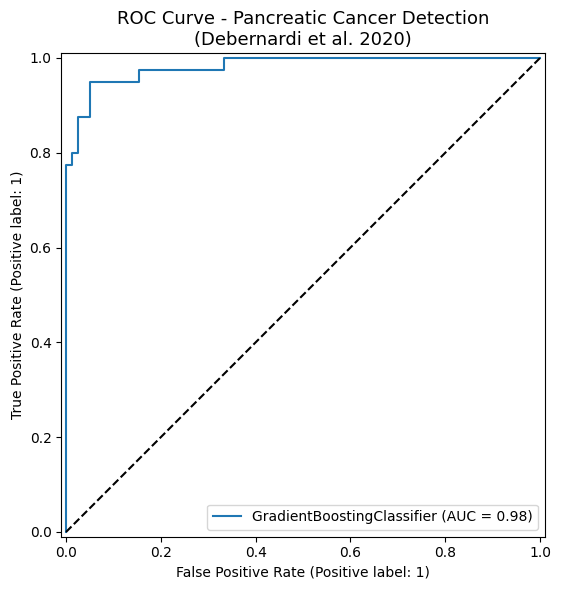

Saved ✅


In [16]:
from sklearn.metrics import RocCurveDisplay

best_model_p.fit(X_p_train, y_p_train)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model_p, X_p_test, y_p_test, ax=ax)
ax.set_title('ROC Curve - Pancreatic Cancer Detection\n(Debernardi et al. 2020)', fontsize=13)
ax.plot([0,1],[0,1],'k--', label='Random classifier')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("Saved ✅")

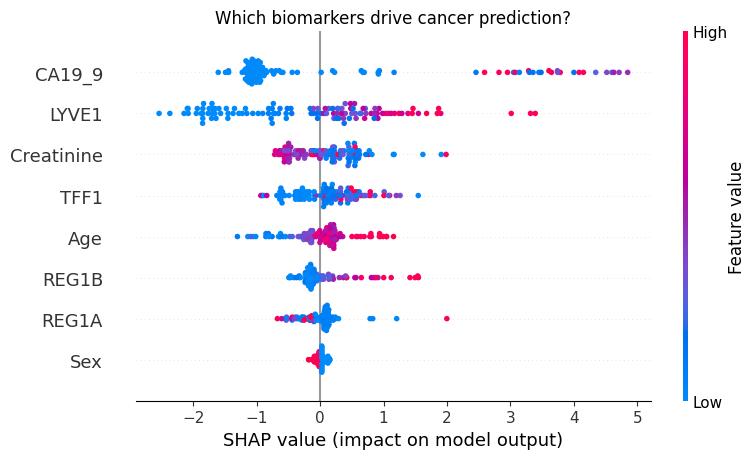

Saved ✅


In [17]:
explainer = shap.TreeExplainer(best_model_p)
shap_values = explainer.shap_values(X_p_test)

plt.figure()
shap.summary_plot(
    shap_values, X_p_test,
    feature_names=['Age','Sex','CA19_9','Creatinine','LYVE1','REG1B','TFF1','REG1A'],
    show=False
)
plt.title("Which biomarkers drive cancer prediction?")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()
print("Saved ✅")

In [18]:
import joblib

best_model_p.fit(X_p, y_p)  # retrain on full data

joblib.dump(best_model_p, '/content/drive/MyDrive/archive/canary_pancreatic_model.pkl')
joblib.dump(list(X_p.columns), '/content/drive/MyDrive/archive/feature_names.pkl')

print("Model saved to Google Drive ✅")
print("Features:", list(X_p.columns))

Model saved to Google Drive ✅
Features: ['age', 'sex', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']


# CANary — Pancreatic Cancer Early Detection Model

## Dataset
- Source: Debernardi et al. 2020, PLOS Medicine
- 590 patients, 14 features
- Classes: Healthy (1), Benign (2), Pancreatic Cancer (3)
- Task: Binary classification — Cancer vs No Cancer

## Methods
- Features: age, sex, plasma_CA19_9, creatinine, LYVE1, REG1B, TFF1, REG1A
- Missing values: filled with column median
- Models tested: Logistic Regression, Random Forest, Gradient Boosting
- Evaluation: 5-fold stratified cross-validation + held-out test set

## Results
| Model | Test AUC |
|---|---|
| Logistic Regression | 0.9641 |
| Random Forest | 0.9761 |
| Gradient Boosting | 0.9817 |

**Best model: Gradient Boosting**
**5-Fold CV AUC: 0.9467 ± 0.0142**

## Key Findings (SHAP)
- CA19_9 is the strongest predictor — high values strongly indicate cancer
- LYVE1 is the second most important biomarker
- Age has moderate predictive value
- Sex has minimal impact

## Limitations
- Small dataset (590 patients)
- Requires external validation on independent cohort
- Not validated for clinical use

## Reference
Debernardi et al. (2020). A combination of urinary biomarkers
improves diagnosis of pancreatic cancer. PLOS Medicine.